In [1]:
#pip install wordcloud


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import os


from scipy.spatial import ConvexHull
from matplotlib.animation import FuncAnimation, PillowWriter

import math
import warnings
warnings.filterwarnings("ignore")

from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator



https://steamdb.info/charts/?sort=peak

In [3]:
SteamsCharts = pd.read_csv("SteamsCharts.csv", sep=";")

In [4]:
SteamsCharts = SteamsCharts.sort_values(by='All-Time Peak')

In [5]:
SteamsCharts_sorted = SteamsCharts.tail(25)

In [6]:
#pip install colour

https://www.flaticon.com/free-icon/game-console_141087

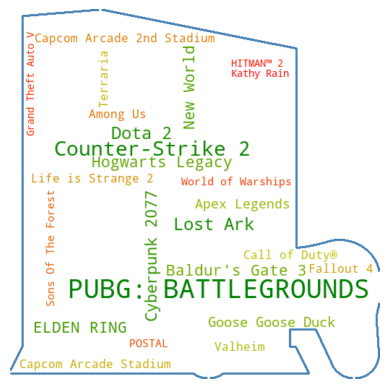

In [7]:
from colour import Color

d = path.dirname(__file__) if "__file__" in locals() else os.getcwd()

ingredients = []
for el in SteamsCharts_sorted['Name']:
    ingredients.append(el)
frequencies = []
for el in SteamsCharts_sorted['All-Time Peak']:
    frequencies.append(el)

D={}
for i in range(len(frequencies)):
    D[ingredients[i]] = frequencies[i]
red = Color("red")
colors = list(red.range_to(Color("green"),SteamsCharts_sorted['Name'].size))
color_values = [c.hex_l for c in colors]
word_colors = {ingredient: color_values[i % len(color_values)] for i, ingredient in enumerate(ingredients)}


console_mask = np.array(Image.open(path.join(d, "console_image.png")))

 

wordcloud = WordCloud(width=1200, height=1200, background_color='white', colormap='viridis',include_numbers=True,collocations = True, repeat = False, min_font_size=12, mask=console_mask, contour_width=3, contour_color='steelblue', color_func=lambda *args, **kwargs: word_colors.get(args[0], 'black')).generate_from_frequencies(D)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")


plt.savefig('Steam_Charts_word_cloud.pdf')
plt.show()

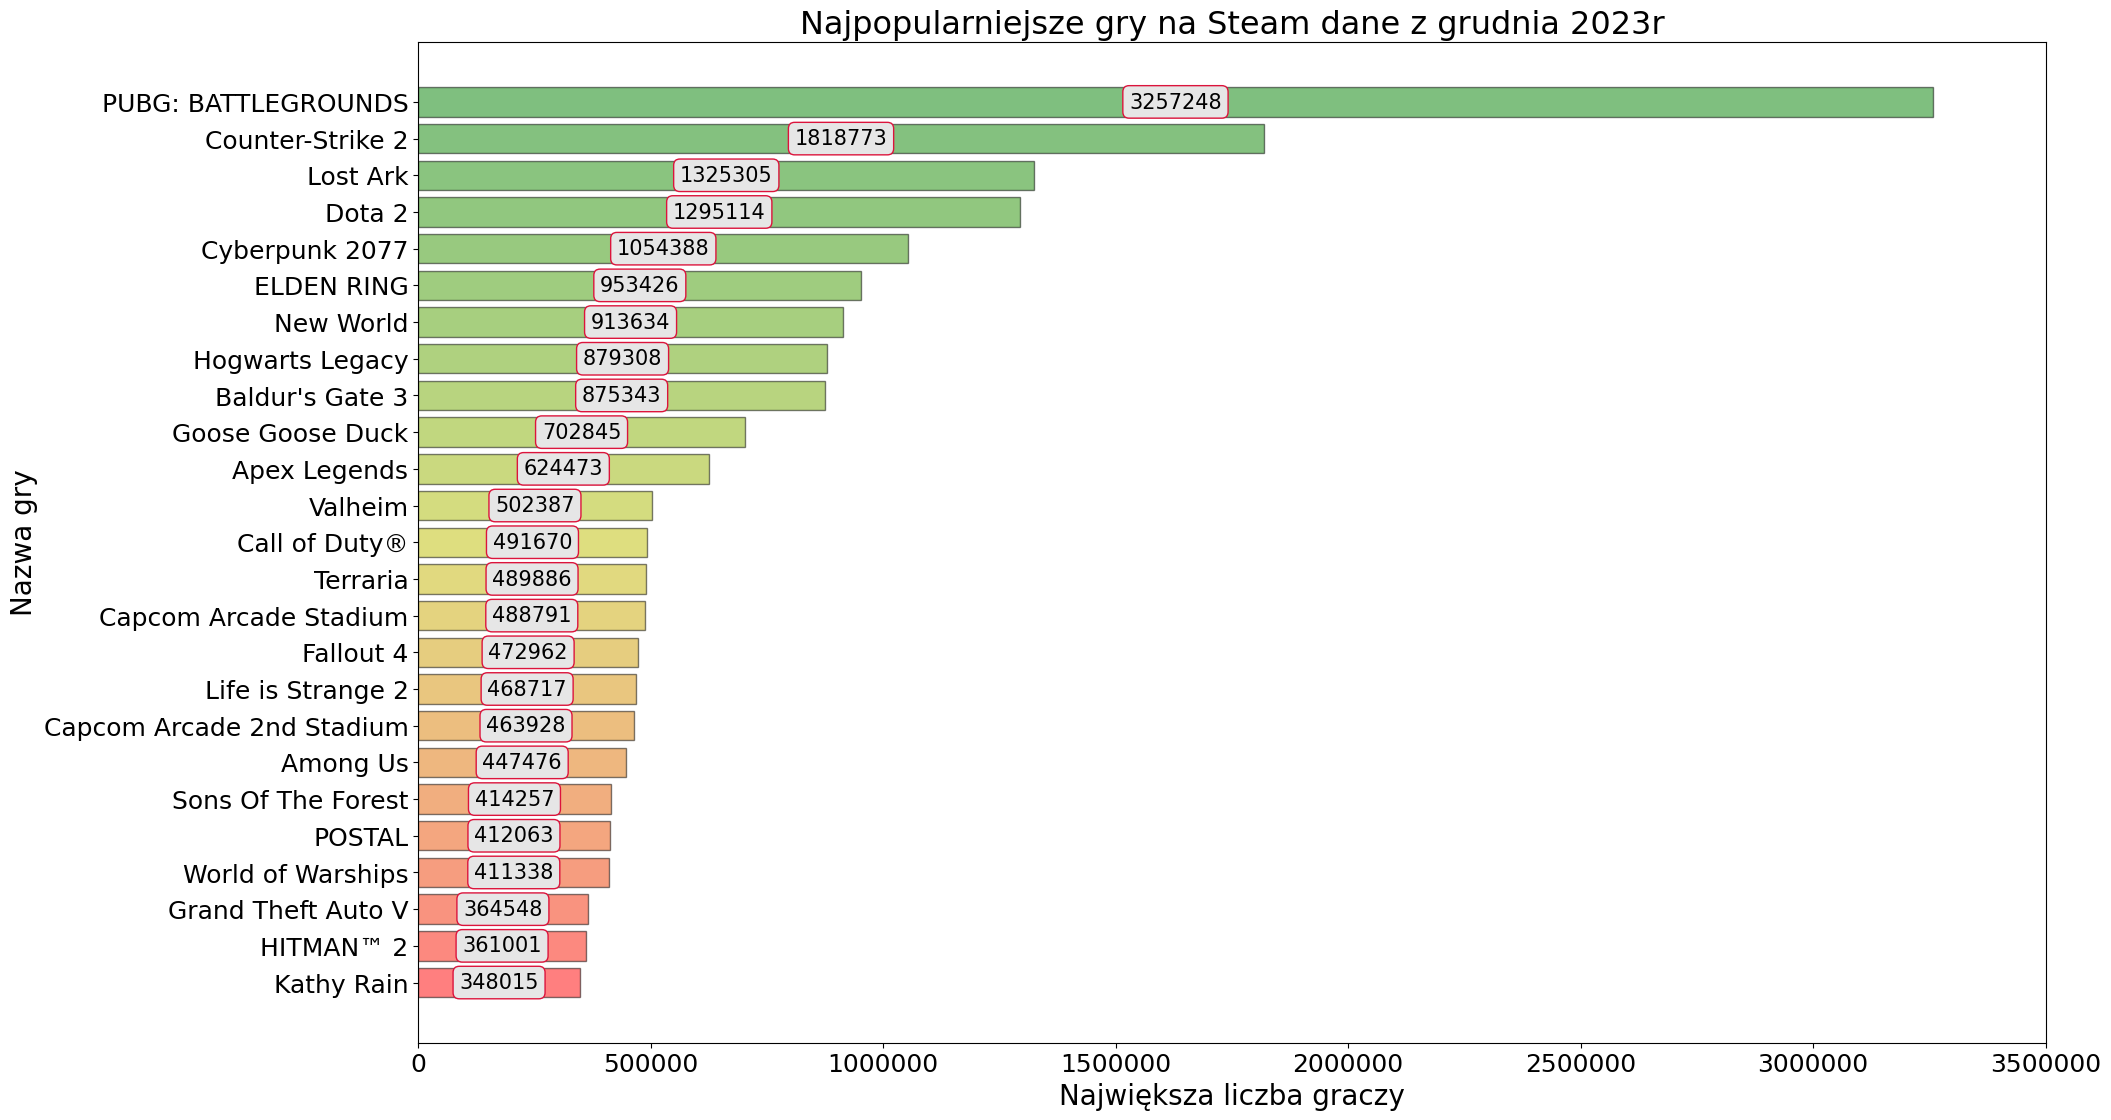

In [8]:
fig, ax = plt.subplots(figsize=(21,13))

bars = ax.barh(SteamsCharts_sorted['Name'], SteamsCharts_sorted['All-Time Peak'], alpha=0.5, edgecolor='black', color=color_values)

for bars in ax.containers:
    ax.bar_label(bars, label_type='center',color='black', bbox = dict(boxstyle="round", fc="0.9",
                 pad = 0.3, ec="crimson"), fmt=lambda x: f'{x:.0f}', fontsize=15)

ax.set_xlim(0,3500000)
ax.set_xticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000])
ax.set_xlabel('Największa liczba graczy', fontsize=20)
ax.set_ylabel('Nazwa gry', fontsize=20)
ax.ticklabel_format(axis='x', style='plain', scilimits=(0,0))
ax.tick_params(axis='both', which='both', labelsize=18)

plt.title('Najpopularniejsze gry na Steam dane z grudnia 2023r', fontsize=23)


plt.savefig('Steam_Charts_barhs.pdf', bbox_inches='tight')
plt.show()